# Task 2 — Yelp Polarity sentiment classification (no pretrained embeddings)
**DATA266 Lab 1 · Member: Shibin Thomas**

The logic lives in tested modules next to this notebook (`data_prep.py`, `models.py`, `train.py`,
`evaluate.py`, `error_analysis.py`); the notebook calls them, so it gives the same results as the
one-command CLI `python task2_sentiment/shibin_thomas/src/run_pipeline.py`.

| Brief section | Where |
|---|---|
| 2.1 Length / class distribution, balance; missing & malformed entries | §1 |
| 2.1 Lowercasing, punctuation, stopwords, stemming; tokenisation; embeddings learned from scratch | §2 |
| 2.2 Baseline + 2 experimental models, architecture & embedding justification | §3, `results.md` |
| 2.2 Full metrics per model; exact CPU/GPU | §4–5 |
| 2.2 Manual review of 20 errors | §6, `failure_analysis.md` |
| 2.3 Comparison, strengths / weaknesses / limitations, future work | §5, `results.md` |

**No pretrained embeddings or language models are used** — every model starts from a randomly initialised `nn.Embedding`.

In [1]:
# ---- Settings -------------------------------------------------------------------------------
MODEL_CONFIGS = ["task2_sentiment/shibin_thomas/configs/baseline_meanpool.yaml",
                 "task2_sentiment/shibin_thomas/configs/exp1_textcnn.yaml",
                 "task2_sentiment/shibin_thomas/configs/exp2_bigru_attn.yaml"]
SMOKE = False            # True -> tiny data, 1 epoch (pipeline check only)
OVERRIDES = []           # e.g. ["training.batch_size=128"]
RUN_TRAINING = "auto"    # "auto": train only if no finished run exists; True / False to force
RUN_ID = "latest"

In [2]:
import sys, json
from pathlib import Path
here = Path.cwd().resolve()
REPO = next((p for p in [here, *here.parents] if (p / "task2_sentiment").is_dir()), None)
assert REPO is not None, "open this notebook from inside the cloned repository"
SRC = REPO / "task2_sentiment" / "shibin_thomas" / "src"
sys.path.insert(0, str(SRC))

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from utils import MEMBER_DIR, read_json, repo_path, run_dirs, get_device, hardware_info
from train import load_model_config
from data_prep import prepare_data, Preprocessor, load_vocab
from models import build_model, count_params

overrides = ([f"data_config=task2_sentiment/shibin_thomas/configs/data_smoke.yaml", "training.epochs=1",
              "smoke=true"] if SMOKE else []) + OVERRIDES
cfgs = [load_model_config(p, overrides) for p in MODEL_CONFIGS]
device = get_device("auto")
print("device:", device, "|", hardware_info(device).get("gpu_name") or hardware_info(device)["cpu_model"])
print("torch", torch.__version__)

device: cuda | NVIDIA GeForce RTX 5090
torch 2.11.0+cu128


## 1. Data analysis, missing values and malformed entries (2.1.1–2.1.2)
The official **test** split (38K reviews) is the test set for every team member; my **validation** split
(50K, stratified, seed 266) is carved out of the official train split (560K).
Malformed rows (missing / non-string text, invalid label, empty after normalising the Yelp dump artefacts)
are dropped; exact duplicates inside train and train reviews that also occur in test (leakage) are removed.

In [3]:
processed = prepare_data(cfgs[0]["data"])
meta = read_json(processed / "meta.json")
print("Malformed / missing report:")
display(pd.DataFrame(meta["malformed_report"]).fillna(0).astype(int))
eda = meta["eda"]
rows = []
for split in ("train_full", "train", "val", "test"):
    e = eda[split]
    rows.append({"split": split, "reviews": e["n"], "negative": e["class_counts"]["negative"],
                 "positive": e["class_counts"]["positive"], "positive rate": round(e["positive_rate"], 4),
                 "balance (min/max)": round(e["balance_ratio_minority_over_majority"], 4),
                 "words mean": round(e["length_words"]["mean"], 1), "words median": e["length_words"]["median"],
                 "words p95": e["length_words"]["p95"], "words max": e["length_words"]["max"]})
display(pd.DataFrame(rows).set_index("split"))
print("mean length (words) by class, train:", eda["train"]["length_words_negative"], eda["train"]["length_words_positive"])

[data] reusing processed data in task2_sentiment/shibin_thomas/data_processed/main (same data config)
Malformed / missing report:


,train,test
rows,560000,38000
kept,560000,38000
duplicates_removed,102,0
train_test_overlap_removed,15,0


,reviews,negative,positive,positive rate,balance (min/max),words mean,words median,words p95,words max
split,,,,,,,,,
train_full,559883,279917,279966,0.5,0.9998,134.1,98.0,375.0,1052.0
train,509883,254919,254964,0.5,0.9998,134.2,98.0,375.0,1052.0
val,50000,24998,25002,0.5,0.9998,133.1,98.0,371.0,1002.0
test,38000,19000,19000,0.5,1.0000,133.6,98.0,371.0,1007.0


mean length (words) by class, train: {'mean': 152.76683181716544, 'median': 113.0, 'p95': 423.0} {'mean': 115.57714814640498, 'median': 85.0, 'p95': 319.0}


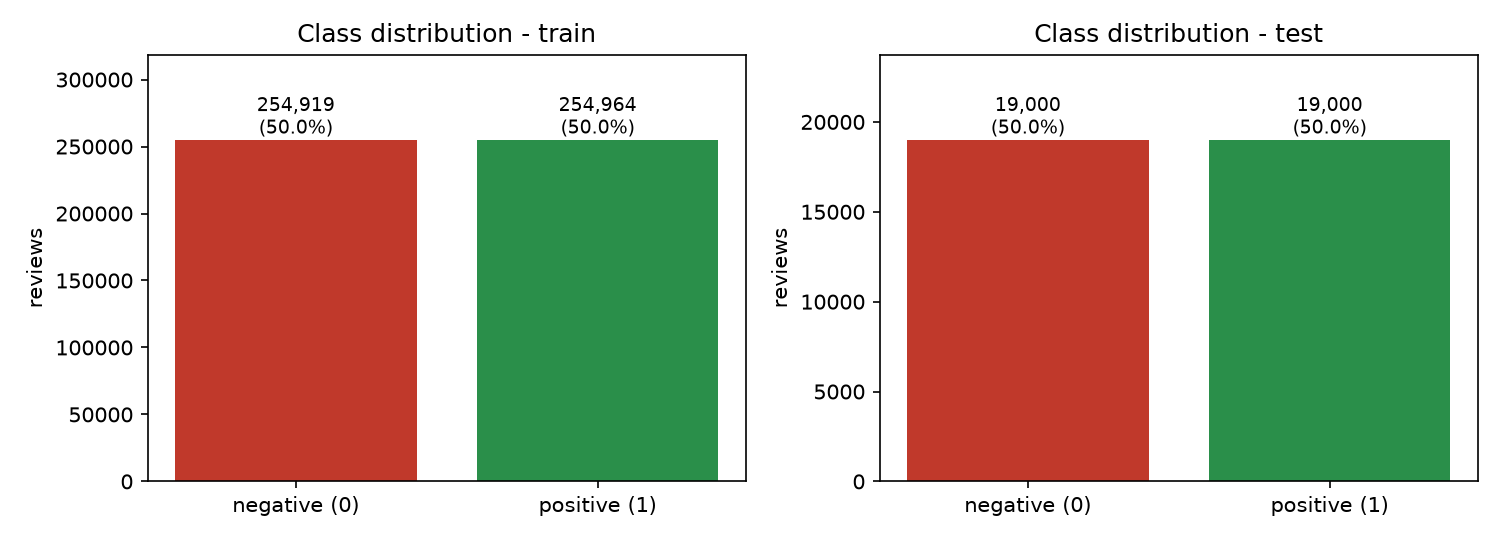

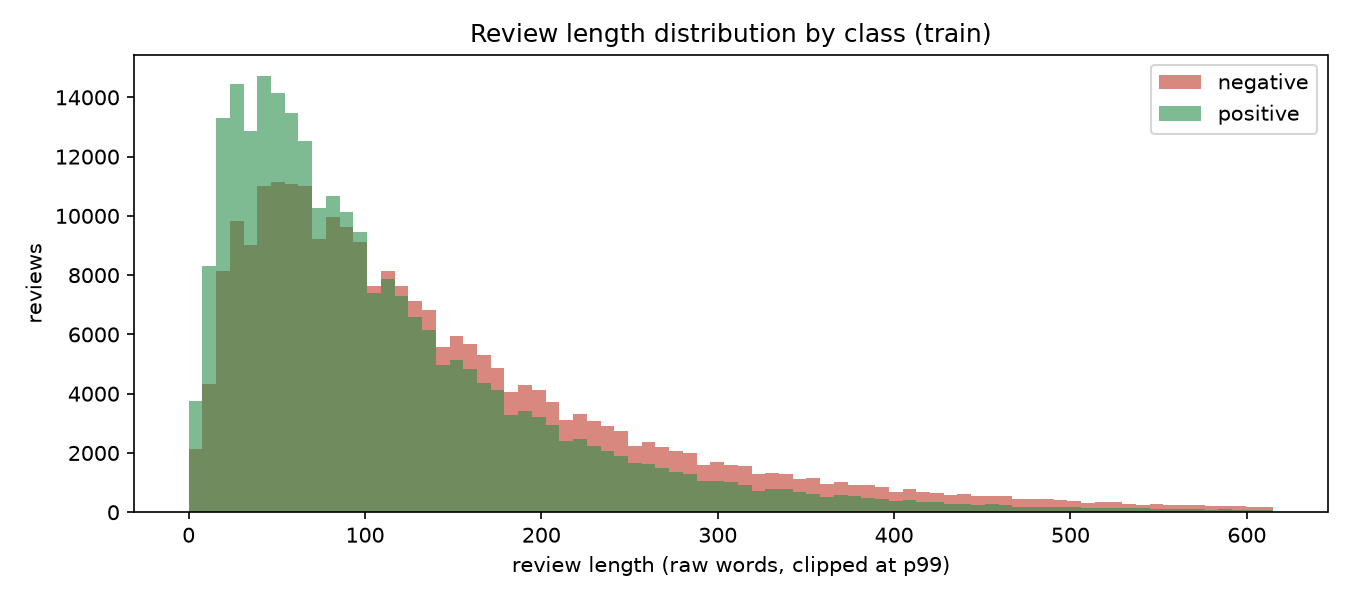

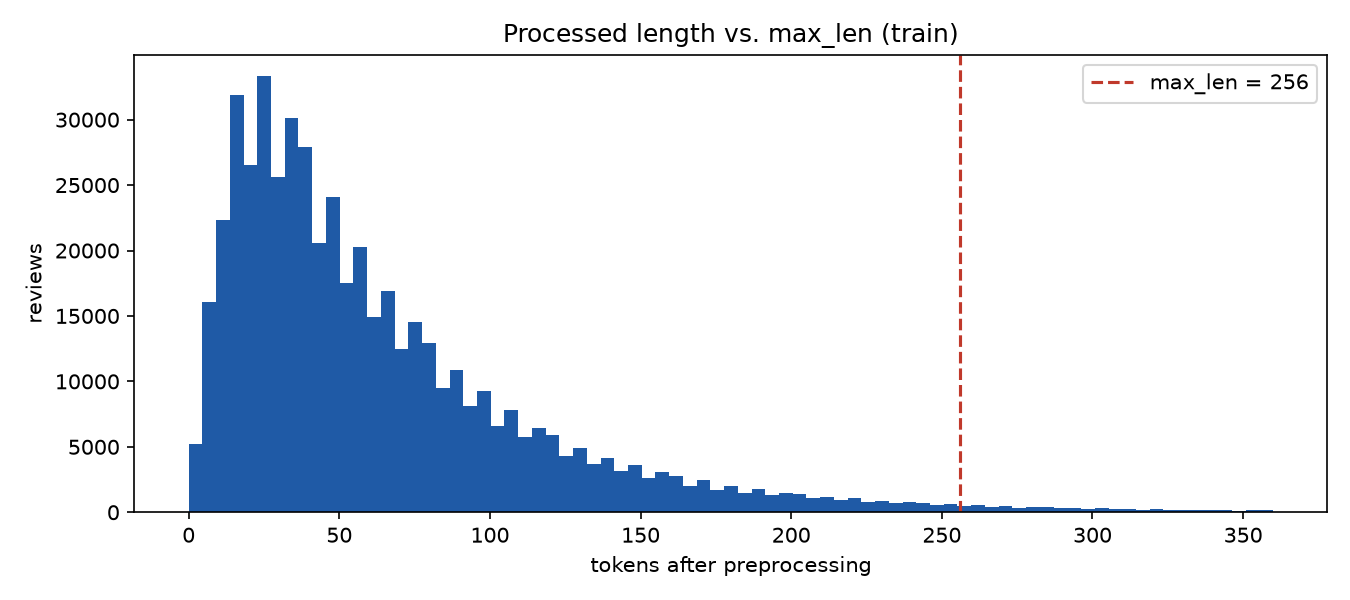

In [4]:
eda_dir = MEMBER_DIR / "outputs" / "eda" / Path(cfgs[0]["data"]["processed_dir"]).name
for f in meta["eda_plots"]:
    display(Image(filename=str(eda_dir / f)))

## 2. Text preprocessing, tokenisation and embeddings (2.1.3–2.1.5)
Steps: normalise dump artefacts → **lowercase** → expand contractions (*didn't → did not*) →
**remove punctuation & special characters** → **remove stopwords** (scikit-learn list, but negations and
contrast words such as *not, no, never, but, however* are deliberately **kept** — dropping *not* would turn
"not good" into "good") → **Snowball stemming** → whitespace **tokenisation** → vocabulary from my training
split (min frequency 3, 30K types) → ids, padded / truncated to 256 tokens with head+tail truncation.
The ids feed an `nn.Embedding` (128-d) that every model **learns from scratch**.

In [5]:
pre = Preprocessor(cfgs[0]["data"])
demo = "The pizza wasn't GOOD at all... but the staff were AMAZING!!! I'd give it 3 stars &amp; come back :)"
display(pd.DataFrame(pre.steps(demo).items(), columns=["step", "text"]))
display(pd.DataFrame(meta["preprocessing_examples"]).T)

,step,text
0,raw,The pizza wasn't GOOD at all... but the staff ...
1,normalised,The pizza wasn't GOOD at all... but the staff ...
2,lowercase,the pizza wasn't good at all... but the staff ...
3,contractions,the pizza was not good at all... but the staff...
4,no_punctuation,the pizza was not good at all but the staff we...
5,no_stopwords,pizza not good but staff amazing 3 stars come
6,stemmed_tokens,pizza not good but staff amaz 3 star come


,0,1,2
raw,"Holy F balls, Friend and I walked in and walke...",The food was good. But our waitress was so rus...,"First off, the service here was great. You ord..."
normalised,"Holy F balls, Friend and I walked in and walke...",The food was good. But our waitress was so rus...,"First off, the service here was great. You ord..."
lowercase,"holy f balls, friend and i walked in and walke...",the food was good. but our waitress was so rus...,"first off, the service here was great. you ord..."
contractions,"holy f balls, friend and i walked in and walke...",the food was good. but our waitress was so rus...,"first off, the service here was great. you ord..."
no_punctuation,holy f balls friend and i walked in and walked...,the food was good but our waitress was so rush...,first off the service here was great you order...
no_stopwords,holy f balls friend walked walked right place ...,food good but waitress rushed stomping finishi...,off service great order counter deliver food t...
stemmed_tokens,holi f ball friend walk walk right place pack ...,food good but waitress rush stomp finish up st...,off servic great order counter deliv food thou...


In [6]:
itos = load_vocab(processed)
s = meta["splits"]
print(f"vocabulary: {len(itos):,} tokens (0=<pad>, 1=<unk>); stopwords removed: {meta['stopwords_removed']}")
display(pd.DataFrame(s).T[["n", "tokens_mean", "tokens_median", "tokens_p95", "truncated_fraction",
                           "oov_token_rate", "empty_after_preprocessing"]])
print("most negative tokens:", eda["most_negative_tokens"][:15])
print("most positive tokens:", eda["most_positive_tokens"][:15])
X = np.load(processed / "X_train.npy", mmap_mode="r"); L = np.load(processed / "len_train.npy")
print("\nexample encoded review:", X[0, :min(20, L[0])].tolist(), "->", " ".join(itos[i] for i in X[0, :min(20, L[0])]))

vocabulary: 30,000 tokens (0=<pad>, 1=<unk>); stopwords removed: 286


,n,tokens_mean,tokens_median,tokens_p95,truncated_fraction,oov_token_rate,empty_after_preprocessing
train,509883.0,66.539714,49.0,184.0,0.017696,0.006684,37.0
val,50000.0,65.993720,49.0,182.0,0.016500,0.007128,2.0
test,38000.0,66.182632,48.0,182.0,0.017211,0.007055,1.0


most negative tokens: ['unprofession', 'rudest', 'unaccept', 'appal', 'incompet', 'disrespect', 'dishonest', 'worst', 'ined', 'unhelp', 'fraud', 'liar', 'tasteless', 'disput', 'accus']
most positive tokens: ['unassum', 'scrumptious', 'mmmmm', 'divin', 'gem', 'yum', 'delish', 'drawback', 'exquisit', 'delect', 'downsid', 'breathtak', 'immacul', 'impecc', 'phenomen']

example encoded review: [2094, 1083, 994, 21, 83, 83, 80, 4, 479, 524, 60, 2, 669, 464, 7, 4384, 994, 1112, 68, 95] -> holi f ball friend walk walk right place pack friday night not bare smell like sweati ball push pretti sure


## 3. Models (2.2.1–2.2.2)
| | Model | Idea | Why |
|---|---|---|---|
| Baseline | **MeanPoolMLP** | masked mean of learned embeddings → MLP | bag-of-words: fast, strong, order-insensitive reference |
| Experiment 1 | **TextCNN** (3/4/5-gram filters, max-over-time) | detects local phrases | captures "not good", "highly recommend" that a bag of words cannot |
| Experiment 2 | **BiGRU + attention** (2 layers) | reads the whole review in order; attention pools | long-range context, contrast ("…but the food was great") |

All three share the same data, vocabulary and a **128-d embedding learned from scratch**, so differences come
from the architecture. Full justification: `results.md`.

In [7]:
vocab_size = len(itos)
for c in cfgs:
    m = build_model(c["model"], vocab_size)
    print(f"--- {c['name']} ({c.get('role')}) : {count_params(m):,} parameters")
    print(m)

--- baseline_meanpool (baseline) : 3,848,321 parameters
MeanPoolMLP(
  (emb): Embedding(30000, 128, padding_idx=0)
  (drop): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
--- exp1_textcnn (experimental) : 4,037,377 parameters
TextCNN(
  (emb): Embedding(30000, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(2,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (drop): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=1, bias=True)
)
--- exp2_bigru_attn (experimental) : 4,367,873 parameters
BiGRUAttention(
  (emb): Embedding(30000, 128, padding_idx=0)
  (emb_drop): Dropout(p=0.3, inplace=False)
  (gru): GRU(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attn_proj): Linea

## 4. Training (early stopping on validation macro-F1)
BCE loss on one logit, AdamW, linear warm-up + cosine decay, gradient clipping, early stopping (patience 2);
the best validation epoch is kept. Logs: `reproducibility/raw_logs/task2_sentiment/shibin_thomas/<run_id>/<model>/`.

In [8]:
from run_pipeline import run_pipeline
prefix = "smoke_yelp3_" if SMOKE else "yelp3_"
names = [c["name"] for c in cfgs]
finished = sorted(p.name for p in (MEMBER_DIR / "outputs").glob(prefix + "*")
                  if all((p / n / "train_summary.json").exists() for n in names) and (p / "comparison.md").exists())
if RUN_TRAINING == "auto":
    RUN_TRAINING = not finished
if RUN_TRAINING:
    RUN_ID = run_pipeline(MODEL_CONFIGS, OVERRIDES, smoke=SMOKE)
elif RUN_ID == "latest":
    RUN_ID = finished[-1]
dirs = run_dirs(RUN_ID)
print("trained now" if RUN_TRAINING else "re-using finished run", "->", RUN_ID)
for n in names:
    print(f"\n{n}:")
    display(pd.read_csv(dirs["raw_logs"] / n / "epochs.csv"))

re-using finished run -> yelp3_20261001-182849

baseline_meanpool:


,epoch,train_loss,val_loss,val_acc,val_f1_macro,val_roc_auc,epoch_time_sec
0,1,0.30607,0.20139,0.92298,0.92298,0.97511,3.1
1,2,0.20468,0.19309,0.92688,0.92688,0.97705,2.6
2,3,0.19206,0.19069,0.92784,0.92784,0.97765,2.6
3,4,0.18511,0.18906,0.92884,0.92884,0.97813,2.6
4,5,0.18005,0.18883,0.92882,0.92882,0.97819,2.6
5,6,0.17701,0.18906,0.92914,0.92914,0.97819,2.6
6,7,0.17484,0.18900,0.92896,0.92896,0.97823,2.6
7,8,0.17410,0.18888,0.92918,0.92918,0.97827,2.6



exp1_textcnn:


,epoch,train_loss,val_loss,val_acc,val_f1_macro,val_roc_auc,epoch_time_sec
0,1,0.28389,0.17143,0.93280,0.93280,0.98202,10.5
1,2,0.17715,0.15568,0.93896,0.93896,0.98519,10.6
2,3,0.15006,0.15003,0.94138,0.94138,0.98627,12.8
3,4,0.13186,0.14734,0.94250,0.94250,0.98668,12.6
4,5,0.12221,0.14762,0.94336,0.94336,0.98678,12.7



exp2_bigru_attn:


,epoch,train_loss,val_loss,val_acc,val_f1_macro,val_roc_auc,epoch_time_sec
0,1,0.23409,0.14913,0.94078,0.94078,0.98661,228.3
1,2,0.14860,0.13459,0.94878,0.94878,0.98909,239.7
2,3,0.12944,0.12864,0.95124,0.95124,0.99021,236.4
3,4,0.11708,0.12946,0.95216,0.95216,0.99058,224.6
4,5,0.11072,0.13106,0.95176,0.95176,0.99069,221.4


## 5. Evaluation on the official test split (2.2.3) and comparison (2.3)
All metrics come from the team's shared definitions in `task2_sentiment/shared_eval/metrics.py`.

In [9]:
display(Markdown((dirs["outputs"] / "comparison.md").read_text(encoding="utf-8")))

# Task 2 model comparison - run `yelp3_20261001-182849`

Official Yelp polarity test split, n = 38,000. McNemar: b = baseline right & model wrong, c = baseline wrong & model right.

| Metric | baseline_meanpool (baseline) | exp1_textcnn (experimental) | exp2_bigru_attn (experimental) |
|---|---|---|---|
| Accuracy | 0.9304 | 0.9467 | 0.9558 |
| Accuracy 95% CI | [0.9276, 0.9330] | [0.9446, 0.9488] | [0.9537, 0.9577] |
| Precision (macro) | 0.9304 | 0.9467 | 0.9558 |
| Recall (macro) | 0.9304 | 0.9467 | 0.9558 |
| F1 (macro) | 0.9304 | 0.9467 | 0.9558 |
| F1 macro 95% CI | [0.9276, 0.9330] | [0.9446, 0.9488] | [0.9537, 0.9577] |
| Precision (micro) | 0.9304 | 0.9467 | 0.9558 |
| Recall (micro) | 0.9304 | 0.9467 | 0.9558 |
| F1 (micro) | 0.9304 | 0.9467 | 0.9558 |
| Precision (weighted) | 0.9304 | 0.9467 | 0.9558 |
| Recall (weighted) | 0.9304 | 0.9467 | 0.9558 |
| F1 (weighted) | 0.9304 | 0.9467 | 0.9558 |
| Confusion matrix [TN FP; FN TP] | [17,718 1,282; 1,363 17,637] | [17,951 1,049; 976 18,024] | [18,029 971; 710 18,290] |
| ROC-AUC | 0.9800 | 0.9883 | 0.9917 |
| PR-AUC | 0.9802 | 0.9885 | 0.9920 |
| MCC | 0.8608 | 0.8934 | 0.9116 |
| MCC 95% CI | [0.8553, 0.8659] | [0.8891, 0.8975] | [0.9076, 0.9155] |
| Brier score | 0.0520 | 0.0399 | 0.0337 |
| ECE (15 bins) | 0.0045 | 0.0049 | 0.0110 |
| McNemar vs baseline (b / c, p) | - (baseline) | 613 / 1,233, p=4.67e-47 | 557 / 1,521, p=4.65e-99 |
| Parameters | 3,848,321 | 4,037,377 | 4,367,873 |
| Training time (min) | 0.3545 | 0.9865 | 19.1767 |
| Epochs run (best) | 8 (8) | 5 (5) | 5 (4) |
| Train examples/sec | 279,909 | 54,074 | 2,271 |
| Inference examples/sec | 2,126,409 | 193,858 | 29,489 |
| Peak GPU memory (MB) | 1,149 | 1,277 | 1,392 |
| Peak CPU RSS (MB, process) | 2,723 | 2,723 | 2,723 |
| Hardware | NVIDIA GeForce RTX 5090 | NVIDIA GeForce RTX 5090 | NVIDIA GeForce RTX 5090 |

## Robustness: macro-F1 / error rate per slice

| Slice (n) | baseline_meanpool macro-F1 / error | exp1_textcnn macro-F1 / error | exp2_bigru_attn macro-F1 / error |
|---|---|---|---|
| all (38,000) | 0.9304 / 0.0696 | 0.9467 / 0.0533 | 0.9558 / 0.0442 |
| short (<=50 words) (9,287) | 0.9277 / 0.0696 | 0.9449 / 0.0529 | 0.9478 / 0.0501 |
| medium (51-150 words) (16,910) | 0.9306 / 0.0694 | 0.9478 / 0.0522 | 0.9591 / 0.0409 |
| long (>150 words) (11,803) | 0.9274 / 0.0700 | 0.9428 / 0.0552 | 0.9541 / 0.0445 |
| has negation (28,544) | 0.9228 / 0.0747 | 0.9433 / 0.0550 | 0.9539 / 0.0448 |
| has contrast (but/however/...) (22,713) | 0.9203 / 0.0789 | 0.9400 / 0.0594 | 0.9509 / 0.0487 |
| no negation & no contrast (6,688) | 0.9263 / 0.0493 | 0.9322 / 0.0453 | 0.9376 / 0.0416 |
| exclamation-heavy (>=3 '!') (6,944) | 0.9490 / 0.0497 | 0.9631 / 0.0359 | 0.9707 / 0.0284 |


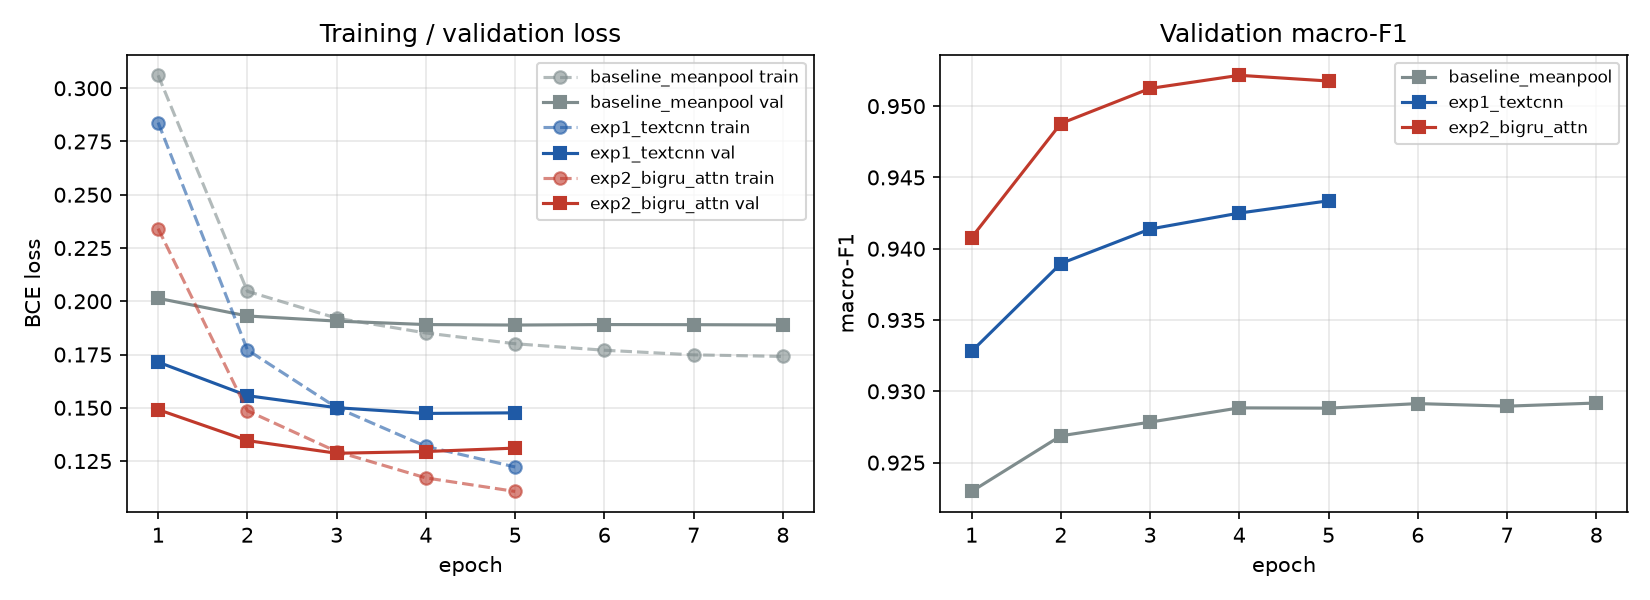

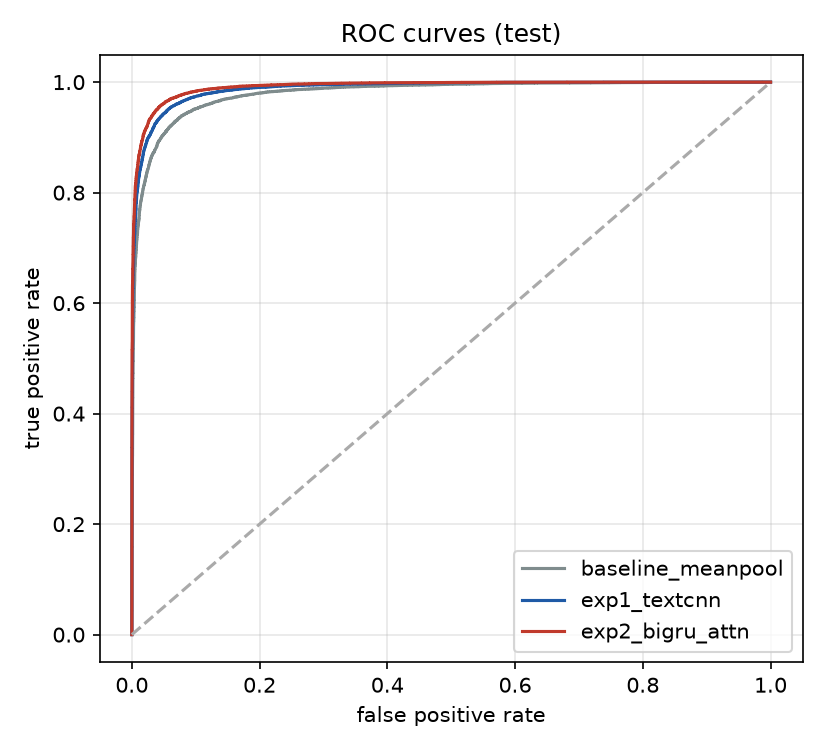

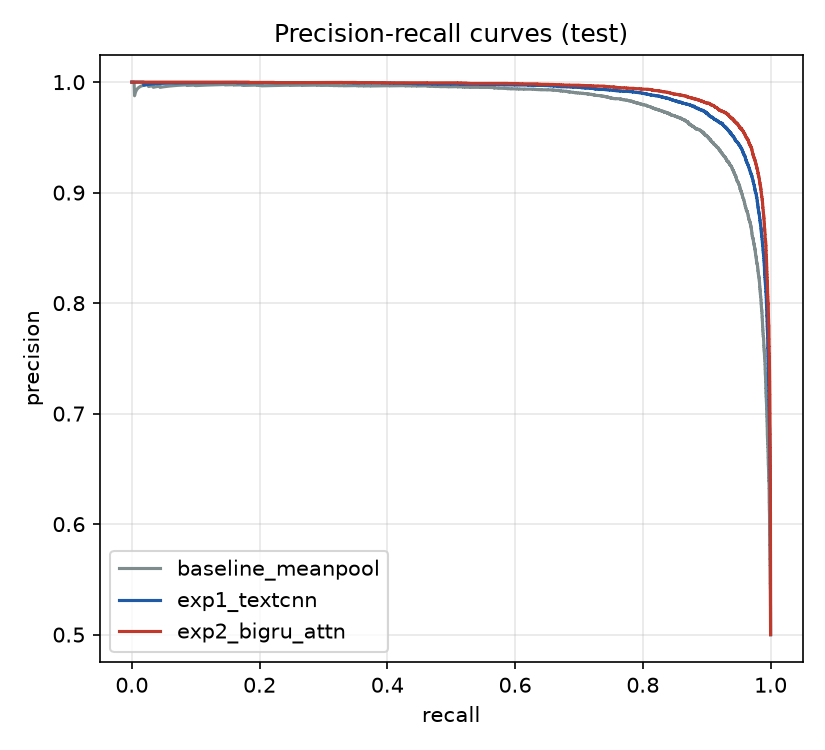

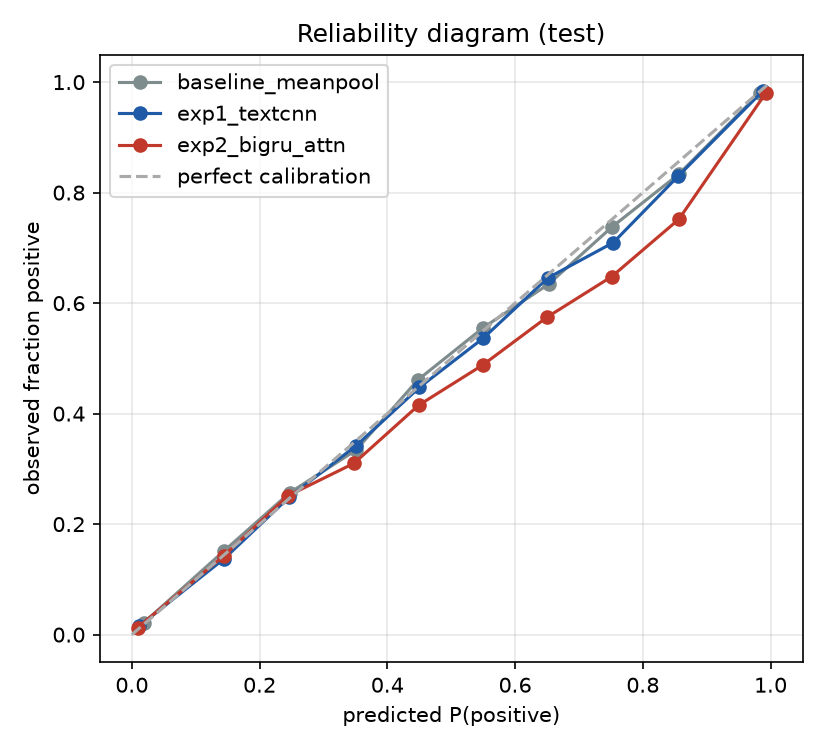

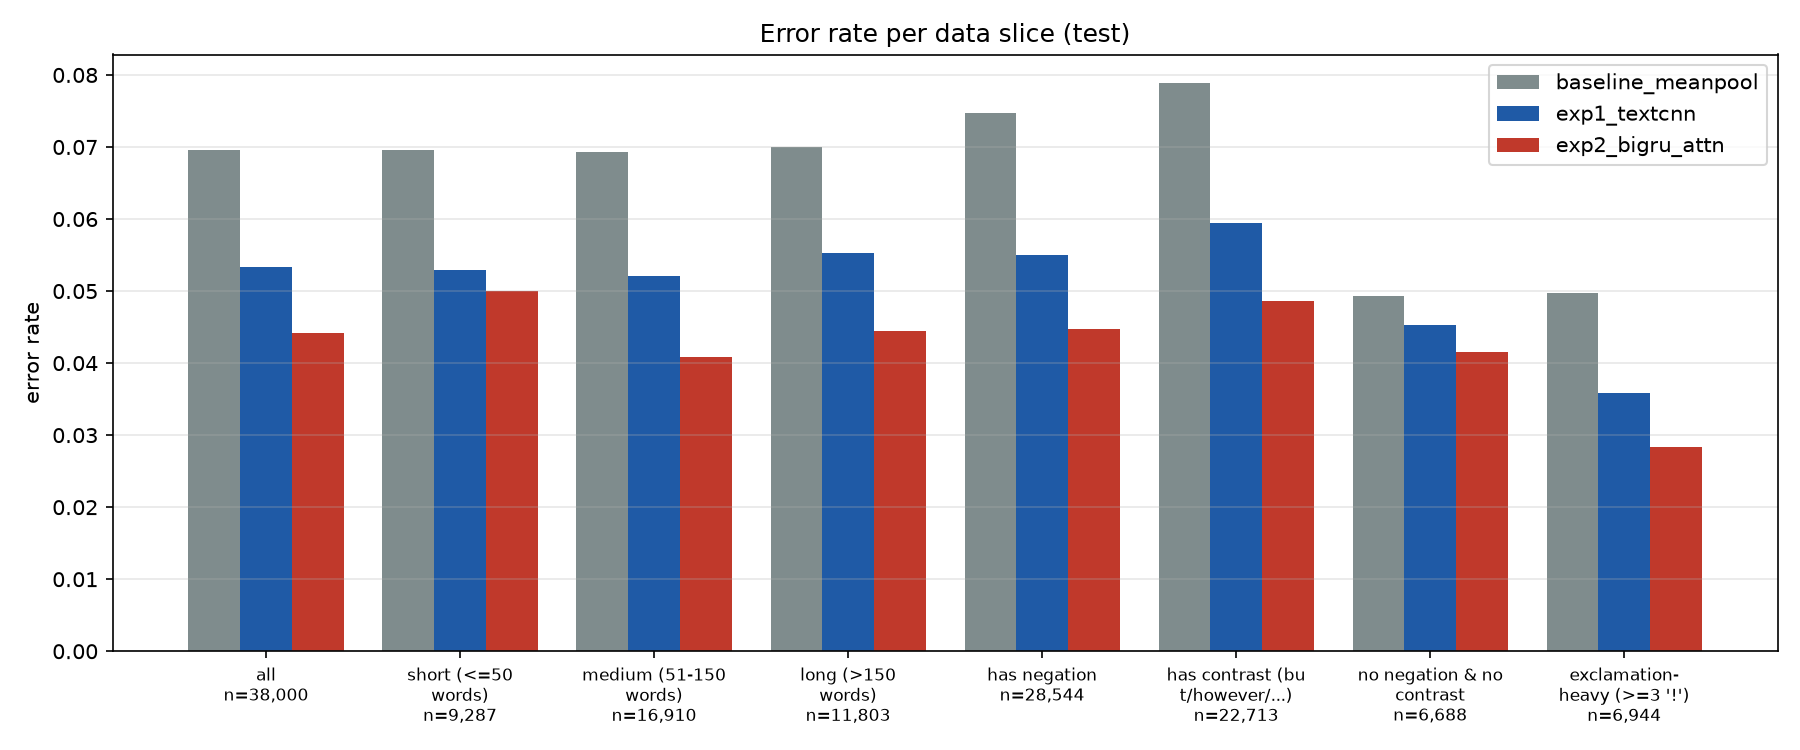

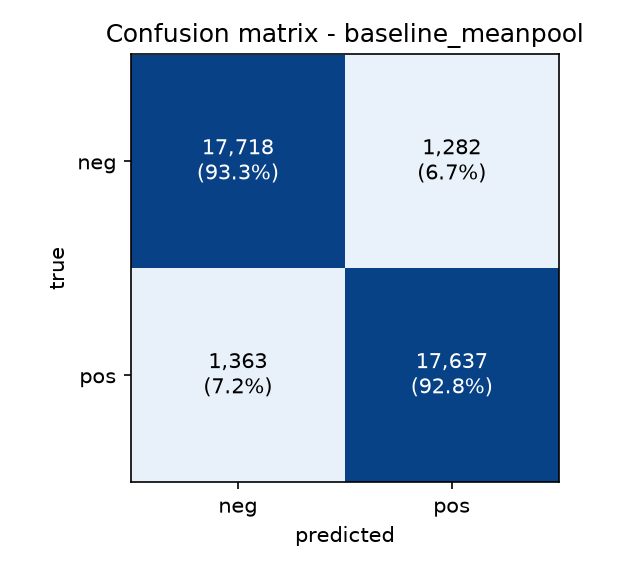

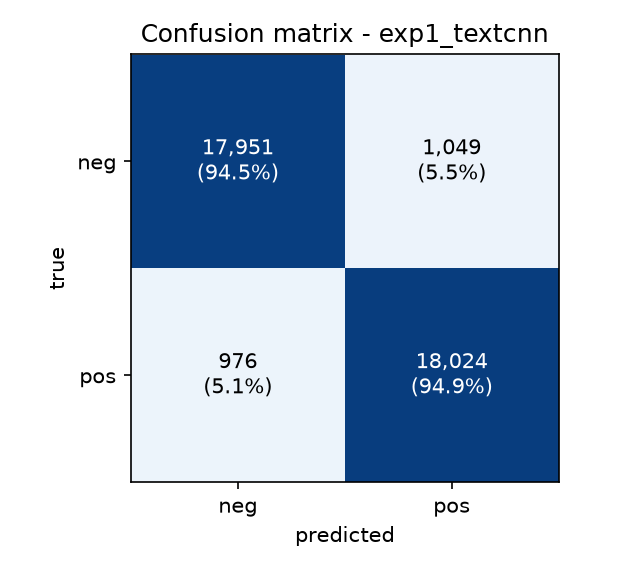

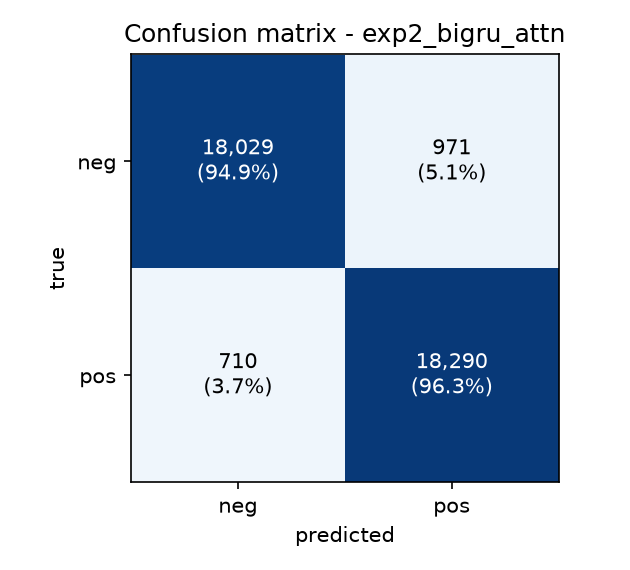

In [10]:
for f in ["training_curves.png", "roc_curves.png", "pr_curves.png", "reliability.png", "slice_error_rates.png"]:
    display(Image(filename=str(dirs["outputs"] / f)))
for n in names:
    display(Image(filename=str(dirs["outputs"] / n / "confusion_matrix.png")))

In [11]:
mc = read_json(dirs["outputs"] / "mcnemar.json")
print("Paired McNemar test, baseline =", mc["baseline"])
display(pd.DataFrame(mc["tests"]).T)
hw = {n: read_json(dirs["outputs"] / n / "train_summary.json")["hardware"] for n in names}
print("Exact hardware per model:")
display(pd.DataFrame(hw).T)

Paired McNemar test, baseline = baseline_meanpool


,b_baseline_only_correct,c_model_only_correct,chi2,p_value,p_value_exact
exp1_textcnn,613.0,1233.0,207.562839,4.673043e-47,6.089403e-48
exp2_bigru_attn,557.0,1521.0,446.279596,4.653566e-99,7.268814e-103


Exact hardware per model:


,device,cpu_model,cpu_count,os,gpu_name,gpu_count,gpu_total_memory_gb,cuda_version,cudnn_version
baseline_meanpool,cuda,"Intel64 Family 6 Model 198 Stepping 2, Genuine...",24,Windows 11,NVIDIA GeForce RTX 5090,1,31.84,12.8,91900
exp1_textcnn,cuda,"Intel64 Family 6 Model 198 Stepping 2, Genuine...",24,Windows 11,NVIDIA GeForce RTX 5090,1,31.84,12.8,91900
exp2_bigru_attn,cuda,"Intel64 Family 6 Model 198 Stepping 2, Genuine...",24,Windows 11,NVIDIA GeForce RTX 5090,1,31.84,12.8,91900


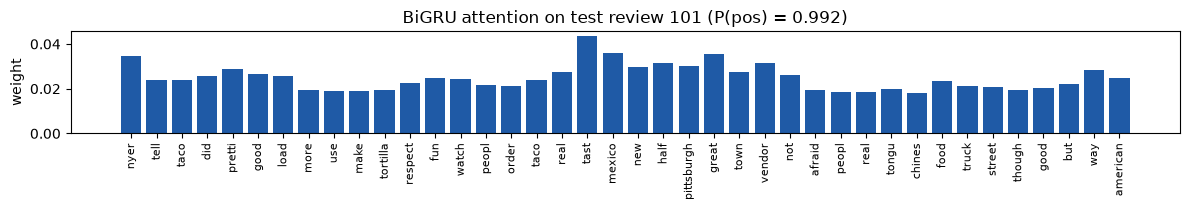

In [12]:
# attention weights of the BiGRU on one test review: which words does it look at?
from evaluate import load_trained
gru_name = next((c["name"] for c in cfgs if c["model"]["type"] == "bigru_attn"), None)
if gru_name:
    model, _ = load_trained(dirs["checkpoints"] / gru_name / "best_model.pt", torch.device("cpu"))
    Xt = np.load(processed / "X_test.npy", mmap_mode="r"); Lt = np.load(processed / "len_test.npy")
    i = int(np.argmin(np.abs(Lt - 40)))
    ids = torch.tensor(np.array(Xt[i:i + 1, :Lt[i]]), dtype=torch.long)
    with torch.no_grad():
        prob = torch.sigmoid(model(ids, torch.tensor([Lt[i]]))).item()
    a = model.last_attention[0].numpy()
    toks = [itos[t] for t in ids[0].tolist()]
    fig, ax = plt.subplots(figsize=(12, 2.2))
    ax.bar(range(len(toks)), a, color="#1f5aa6"); ax.set_xticks(range(len(toks)), toks, rotation=90, fontsize=8)
    ax.set(title=f"BiGRU attention on test review {i} (P(pos) = {prob:.3f})", ylabel="weight")
    fig.tight_layout(); display(fig); plt.close(fig)

## 6. Manual review of 20 errors (2.2.4)
`error_analysis.py` takes my best model (by validation macro-F1) and selects 5 confident false positives,
5 confident false negatives, 5 near-threshold errors and 5 failures from the slice with the highest error rate.
I read each review, confirmed or corrected the error type and proposed a testable fix in
[`failure_analysis.md`](../failure_analysis.md).

In [13]:
fa = MEMBER_DIR / "failure_analysis.md"
src = fa if (fa.exists() and not SMOKE) else dirs["outputs"] / "error_candidates.md"
display(Markdown(src.read_text(encoding="utf-8")))

<!-- AUTO-DRAFT: generated by src/error_analysis.py from run yelp3_20261001-182849. Read every review, confirm or correct the error type and edit the notes in your own words; once you delete this line the file is never overwritten again. -->
# Task 2.2.4 - Manual review of 20 errors

**Model reviewed:** `exp2_bigru_attn` (highest validation macro-F1 of my three models) - run `yelp3_20261001-182849`.
**Data:** official Yelp polarity test split (n = 38,000), threshold 0.5, 1,681 errors in total.
**Hardest slice:** `short (<=50 words)` (error rate 5.01%; all slice error rates: short (<=50 words) 5.01%, has contrast (but/however/...) 4.87%, has negation 4.48%, long (>150 words) 4.45%, no negation & no contrast 4.16%, medium (51-150 words) 4.09%, exclamation-heavy (>=3 '!') 2.84%).

| # | Group | Test idx | True | P(pos) | Error type | Evidence |
|---|---|---|---|---|---|---|
| 1 | Confident false positive | 23815 | negative | 1.000 | Mixed sentiment (contrast) | contrast words: ['but'] |
| 2 | Confident false positive | 29330 | negative | 1.000 | Possible label noise / sarcasm | confident (p=1.000) with no structural cue |
| 3 | Confident false positive | 408 | negative | 1.000 | Mixed sentiment (contrast) | contrast words: ['but', 'though'] |
| 4 | Confident false positive | 22663 | negative | 1.000 | Mixed sentiment (contrast) | contrast words: ['but'] |
| 5 | Confident false positive | 8426 | negative | 1.000 | Mixed sentiment (contrast) | contrast words: ['but', 'despite'] |
| 6 | Confident false negative | 22807 | positive | 0.000 | Mixed sentiment (contrast) | contrast words: ['but'] |
| 7 | Confident false negative | 22451 | positive | 0.001 | Explicit star rating ignored | mentions [4] star(s) |
| 8 | Confident false negative | 27334 | positive | 0.001 | Explicit star rating ignored | mentions [4] star(s) |
| 9 | Confident false negative | 21215 | positive | 0.001 | Negation / polarity shift | negations: ['no', 'none', 'not'] |
| 10 | Confident false negative | 11808 | positive | 0.001 | Mixed sentiment (contrast) | contrast words: ['but'] |
| 11 | Near-threshold error | 20397 | positive | 0.499 | Mixed sentiment (contrast) | contrast words: ['but', 'however'] |
| 12 | Near-threshold error | 18529 | positive | 0.498 | Explicit star rating ignored | mentions [4] star(s) |
| 13 | Near-threshold error | 28403 | positive | 0.498 | Mixed sentiment (contrast) | contrast words: ['however'] |
| 14 | Near-threshold error | 29624 | negative | 0.502 | Negation / polarity shift | negations: ["n't", 'not'] |
| 15 | Near-threshold error | 14124 | positive | 0.497 | Weak / ambiguous sentiment | p=0.497; no contrast, negation, rating or truncation cue |
| 16 | Slice-specific failure (short (<=50 words)) | 20439 | negative | 0.999 | Negation / polarity shift | negations: ['never'] |
| 17 | Slice-specific failure (short (<=50 words)) | 12480 | negative | 0.999 | Mixed sentiment (contrast) | contrast words: ['but'] |
| 18 | Slice-specific failure (short (<=50 words)) | 26683 | positive | 0.002 | Mixed sentiment (contrast) | contrast words: ['despite'] |
| 19 | Slice-specific failure (short (<=50 words)) | 33573 | positive | 0.002 | Possible label noise / sarcasm | confident (p=0.002) with no structural cue |
| 20 | Slice-specific failure (short (<=50 words)) | 20058 | negative | 0.998 | Possible label noise / sarcasm | confident (p=0.998) with no structural cue |

## The 20 reviews

**1. Confident false positive** - true negative, P(pos) = 1.000, 106 tokens after preprocessing - *Mixed sentiment (contrast)*

> This is the neighborhood Foodland that has the bare necessities needed to sustain a pantry or for when the next snowstorm of the century is a day away and you only have minutes to get TP, bread and milk. The bakery here is tops, small selection, but really well made specialities. Huge brownies, iced and moist. They are easily 5 inch squares, topped with things like Oreo cookies, nuts, sprinkles, a ...

**2. Confident false positive** - true negative, P(pos) = 1.000, 19 tokens after preprocessing - *Possible label noise / sarcasm*

> Wow love the place and everything is very clean and new! Great place to come and relax worth a try! Cheers, Eric Van Nguyen Visited April 2012

**3. Confident false positive** - true negative, P(pos) = 1.000, 62 tokens after preprocessing - *Mixed sentiment (contrast)*

> Though I'm a Copper enthusiast when it comes to getting my Indian fix in Charlotte, I'd heard that Maharani was a cheaper but tasty option, so we ordered from there a few nights ago. Copper is definitely still my place, but Maharani was fine enough. First of all, the food came very quickly, which is rare. Usually indian food, good indian good, takes at least 30-45 minutes. We got our order in like ...

**4. Confident false positive** - true negative, P(pos) = 1.000, 97 tokens after preprocessing - *Mixed sentiment (contrast)*

> About average so far as steakhouses go. My rib eye was very tasty but a little over cooked. I didn't complain because the flavor was still fantastic. I thought the process were quite out of order. I've had better for sell. Over all I'd say they are more for show than content. If you want to have a great high end steak I'd recommend Ruth Chris, LG's, Flemings, or Morton's. If you want to show off h ...

**5. Confident false positive** - true negative, P(pos) = 1.000, 231 tokens after preprocessing - *Mixed sentiment (contrast)*

> Saturday / Sunday AYCE brunch In true las vegas fashion, you get a flat rate to eat your heart out. For Strip food, main menu items seem reasonably priced and the brunch is cheap at $29.99. There are a few different flavors to choose from for the All-You-Can-Drink Bottomless mimosas. They're $5 per person; but on multiple occasions, the $5 was comped for me and my dining partner. Maybe its a local ...

**6. Confident false negative** - true positive, P(pos) = 0.000, 49 tokens after preprocessing - *Mixed sentiment (contrast)*

> EDIT: They really did change the service up since I last posted this. Horrible service. Used to be my favorite pizza in the city (at a reasonable price), but I'm rethinking that. We just had an altercation with a server who refused to split a check when we were paying with cash. He then proceeded to disrespect the party at the table, telling us to 'not give him attitude about it.' Sorry Bella Nott ...

**7. Confident false negative** - true positive, P(pos) = 0.001, 113 tokens after preprocessing - *Explicit star rating ignored*

> The food is crap. I'm not trying to be mean, but it really is horrible. I'd rather eat one of those Tornado things from Circle K for dinner. Also, I don't appreciate the waitress telling me everything is great when everything is absolutely not great. What kind of disgusting excuse for food must she live off of if the nachos get her stamp of approval? They were probably the worst nachos I've ever h ...

**8. Confident false negative** - true positive, P(pos) = 0.001, 75 tokens after preprocessing - *Explicit star rating ignored*

> A note to the owners of Cupcrazed: Your staff are overriding the brilliance of your product. For a company that has something great to brag about as this place does, the employees seem dis-interested and completely unmotivated. Having arrived two hours before closing, and similar to other reports, the chairs were upside down on the tables sending a clear message that closing can't come fast enough ...

**9. Confident false negative** - true positive, P(pos) = 0.001, 84 tokens after preprocessing - *Negation / polarity shift*

> Last night several parents came in with over 15 children to celebrate their 9 year olds 4th grade graduation at 9:15 pm. The bartender expressed that it was not a place to have children running around as it is against the law and a liability issue if anything were to happen to them on their premise. The children were running in and out of the bar while the parents continued to drink upstairs claim ...

**10. Confident false negative** - true positive, P(pos) = 0.001, 108 tokens after preprocessing - *Mixed sentiment (contrast)*

> It was Anniversary time! But we didn't' want to spend a ton of money on food or booze. Plus, were weren't interested in going to a show at the time. So, what to do? Aquarium! Don't get me wrong: This place is TINY! Narrow walk ways and close quarters in general. Even the exhibits are small. I do hope that all of the animals in there are ok. They do seem treated well but I wonder if they would be h ...

**11. Near-threshold error** - true positive, P(pos) = 0.499, 361 tokens after preprocessing - *Mixed sentiment (contrast)*

> Went straight from work to check out Mekong Plaza last night after chatting with coworker ""JJ"" about the good deals she found there. She was able to find her fave brand of rice, grapes, garlic, and other items. She was lamenting that she only had twenty minutes to look around; she therefore allowed herself to buy those items she knew cost less here than at Lee Lee. After she'd listed off what sh ...

**12. Near-threshold error** - true positive, P(pos) = 0.498, 175 tokens after preprocessing - *Explicit star rating ignored*

> As with all my reviews, my review of Teharu will compare the food relative to price. Who cares about service right? Go to China and tell me about service. Food is first and foremost. Nigiri. $1 - Salmon: average quality for being priced at $1, wait how can I say that since I've never had $1 salmon nigiri???? its $1 and throughout my 4 years of going here, not once has it had a fishy smell. No fish ...

**13. Near-threshold error** - true positive, P(pos) = 0.498, 33 tokens after preprocessing - *Mixed sentiment (contrast)*

> Their alcohol selection sucks, as in they ran out of everything they said they had. I had to have a Sapphire tonic...SAPPHIRE, PEOPLE!!! The waiter said she had Hendricks and then dreamcrushed my cocktail dreams. My other friend wanted a beer and 8 of the beers he wanted they were ""out of"". However, the burger was nice, very juicy and rare. Plus, the more you drink the better everything tastes,  ...

**14. Near-threshold error** - true negative, P(pos) = 0.502, 77 tokens after preprocessing - *Negation / polarity shift*

> Overly sentimental, non stop references to her kids, how blessed she is, and her husband.... too many covers from elite performers like Stevie Wonder.... Billy Joel...Tina Turner. Why is she not just playing her music.. as an elite performer herself? A weird duet sung between herself and a computer generation of herself... and then back to back with another one...a computer generated Stevie Wonder ...

**15. Near-threshold error** - true positive, P(pos) = 0.497, 22 tokens after preprocessing - *Weak / ambiguous sentiment*

> Wow,I placed an order here last night and the pizza was to my door in 15 minutes! I got a pepperoni pizza with a chocolate chip cookie and the cookie's are to die for. Also if you order online there are a lot of good deals going on.

**16. Slice-specific failure (short (<=50 words))** - true negative, P(pos) = 0.999, 16 tokens after preprocessing - *Negation / polarity shift*

> Standard take out and it's cheap. Service is fast and friendly. I go here when I'm too lazy to walk to Zaw's or pressed for time (I've never had to wait longer than 15 minutes).

**17. Slice-specific failure (short (<=50 words))** - true negative, P(pos) = 0.999, 12 tokens after preprocessing - *Mixed sentiment (contrast)*

> my husband had an omelette that was good. i had a blt, a little on the small side for $10, but bacon was great. Our server was awesome!

**18. Slice-specific failure (short (<=50 words))** - true positive, P(pos) = 0.002, 16 tokens after preprocessing - *Mixed sentiment (contrast)*

> I've just been forced to concede that, despite still not digging their ordering process, their food is just too good to disrespect with a 2 star review.

**19. Slice-specific failure (short (<=50 words))** - true positive, P(pos) = 0.002, 14 tokens after preprocessing - *Possible label noise / sarcasm*

> For being a DUMP, should expect much more. Flys, stink, garbage, dirt, and everything that comes with. Salt River... Keepin it real dumpy!

**20. Slice-specific failure (short (<=50 words))** - true negative, P(pos) = 0.998, 8 tokens after preprocessing - *Possible label noise / sarcasm*

> Meat and two place. Pretty decent food. Great service. Divey.

## Error types found

| Error type | Count | Testable fix (and how to measure it) |
|---|---|---|
| Mixed sentiment (contrast) | 10 | weight the clause after 'but/however' (e.g. split on contrast words and add a 'post-contrast' feature) - measure macro-F1 on the has-contrast slice |
| Possible label noise / sarcasm | 3 | manually relabel a sample of confident errors to estimate label noise; sarcasm needs context the model lacks |
| Explicit star rating ignored | 3 | keep rating phrases as single tokens ('5_star', 'one_star') before stopword removal - measure on reviews that mention stars |
| Negation / polarity shift | 3 | negation marking: prefix tokens after a negation with NOT_ until the next punctuation - measure macro-F1 on the has-negation slice |
| Weak / ambiguous sentiment | 1 | calibrate and abstain near 0.5 (selective prediction) - measure accuracy vs coverage |

## Proposed testable fix

The most frequent error type is **Mixed sentiment (contrast)** (10 of 20). Fix: weight the clause after 'but/however' (e.g. split on contrast words and add a 'post-contrast' feature) - measure macro-F1 on the has-contrast slice. Test it by retraining the same model with only this change and comparing the slice metric and overall macro-F1 against the current model with a paired McNemar test on the same test reviews.


## 7. Evidence trail
* Raw logs (unedited): `reproducibility/raw_logs/task2_sentiment/shibin_thomas/<run_id>/`
* Manifest (versions, hardware, git commit, config hashes, checkpoint SHA-256): `reproducibility/manifests/task2_sentiment/shibin_thomas/<run_id>.json`
* Checkpoints: `task2_sentiment/shibin_thomas/checkpoints/<run_id>/<model>/best_model.pt`
* All metrics: `metrics_report.csv` · comparison: `comparison.md` · write-up: `results.md`, `failure_analysis.md`